# Assignment -Regression & Its Evaluation 

Q-1 What is Simple Linear Regression?

Ans- Simple Linear Regression is a statistical and machine-learning method used to understand the relationship between one independent variable (X) and one dependent variable (Y) by fitting a straight line through the data points.

It assumes that the dependent variable changes linearly with the independent variable.

Q-2 What are the key assumptions of Simple Linear Regression?

Ans- 
   1. Linear Relationship-There must be a straight-line relationship between the independent variable (X) and the dependent variable (Y).

   2. Independence - Each data point should be independent of others (one observation should not affect another).

   3. Homoscedasticity (Constant Variance) - The errors (differences between actual and predicted values) should have the same spread for all values of X.

  4. Normal Distribution of Errors- The error terms should be normally distributed around zero.

  5. No Outliers- There should be no extreme values that strongly affect the regression line.

Q-3 What is heteroscedasticity, and why is it important to address in regression
models?

Ans-  Heteroscedasticity occurs in a regression model when the variance of the error terms is not constant across all values of the independent variable.
In simple words, the spread of residuals increases or decreases as the value of X changes.

  - Heteroscedasticity Important to Address:

 1. Unreliable Standard Errors
It leads to incorrect standard errors, making hypothesis tests unreliable.

2. Wrong p-values and Confidence Intervals
You may incorrectly conclude a variable is significant or insignificant.

3. Poor Model Interpretation
Coefficient estimates remain unbiased, but their accuracy is affected.

4. Violates Regression Assumptions
This reduces the overall reliability of the regression model.


Q-4  What is Multiple Linear Regression?

Ans- Multiple Linear Regression (MLR) is a statistical technique used to model the relationship between one dependent variable (Y) and two or more independent variables (X₁, X₂, …, Xₙ).

It helps us understand how multiple factors together affect an outcome.
 
   - Use of Multiple Linear Regression:

     - To analyze the effect of many variables at the same time

     - To make more accurate predictions

     - To control the influence of other factors


Q-5 What is polynomial regression, and how does it differ from linear
regression?

Ans- Polynomial Regression is a type of regression technique where the relationship between the independent variable (X) and the dependent variable (Y) is modeled as a polynomial curve (not a straight line).

It is used when data shows a curved or non-linear trend.

     - How does it differ from linear
 Polynomial regression differs from linear regression in the form of the relationship it models between variables. Linear regression assumes a straight-line relationship between the independent and dependent variables, meaning the change in the output is constant for a unit change in the input. In contrast, polynomial regression allows the relationship to be curved by including higher-order terms (such as squared or cubed values of the independent variable). This makes polynomial regression more flexible and suitable for modeling non-linear patterns in data. However, this added flexibility increases model complexity and the risk of overfitting, whereas linear regression is simpler, easier to interpret, and works best when the true relationship is approximately linear.

Q6: Implement a Python program to fit a Simple Linear Regression model to the following sample data:

 -  X = [1, 2, 3, 4, 5]
 -  Y = [2.1, 4.3, 6.1, 7.9, 10.2]

Plot the regression line over the data points.


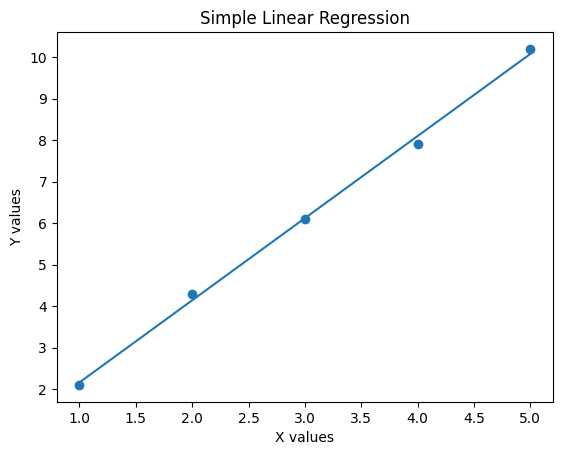

In [2]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Given data
X = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
Y = np.array([2.1, 4.3, 6.1, 7.9, 10.2])

# Create and fit the model
model = LinearRegression()
model.fit(X, Y)

# Predict values
Y_pred = model.predict(X)

# Plot data points and regression line
plt.scatter(X, Y)
plt.plot(X, Y_pred)
plt.xlabel("X values")
plt.ylabel("Y values")
plt.title("Simple Linear Regression")
plt.show()


Q-7 : Fit a Multiple Linear Regression model on this sample data:

  -  Area = [1200, 1500, 1800, 2000]
  -  Rooms = [2, 3, 3, 4]
  - Price = [250000, 300000, 320000, 370000]
 
Check for multicollinearity using VIF and report the results.


In [6]:
#!pip install statsmodels
import pandas as pd
from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Sample data
data = pd.DataFrame({
    'Area': [1200, 1500, 1800, 2000],
    'Rooms': [2, 3, 3, 4],
    'Price': [250000, 300000, 320000, 370000]
})

# Independent variables
X = data[['Area', 'Rooms']]

# Fit Multiple Linear Regression model
model = LinearRegression()
model.fit(X, data['Price'])

# Calculate VIF
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) 
                   for i in range(X.shape[1])]

vif_data


,Feature,VIF
0,Area,127.796923
1,Rooms,127.796923


Q8: Implement polynomial regression on the following data:

- X = [1, 2, 3, 4, 5]
- Y = [2.2, 4.8, 7.5, 11.2, 14.7]

Fit a 2nd-degree polynomial and plot the resulting curve.



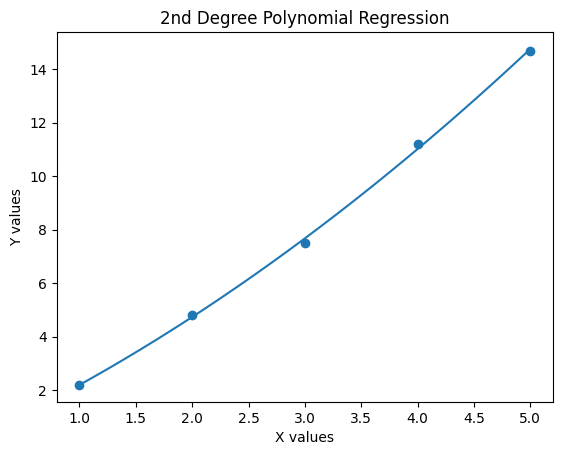

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Given data
X = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
Y = np.array([2.2, 4.8, 7.5, 11.2, 14.7])

# Create polynomial features of degree 2
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

# Fit the polynomial regression model
model = LinearRegression()
model.fit(X_poly, Y)

# Generate smooth curve for plotting
X_range = np.linspace(1, 5, 100).reshape(-1, 1)
X_range_poly = poly.transform(X_range)
Y_pred = model.predict(X_range_poly)

# Plot the data points and polynomial curve
plt.scatter(X, Y)
plt.plot(X_range, Y_pred)
plt.xlabel("X values")
plt.ylabel("Y values")
plt.title("2nd Degree Polynomial Regression")
plt.show()


Q9: Create a residuals plot for a regression model trained on this data:
- X = [10, 20, 30, 40, 50]
- Y = [15, 35, 40, 50, 65]
 
Assess heteroscedasticity by examining the spread of residuals.



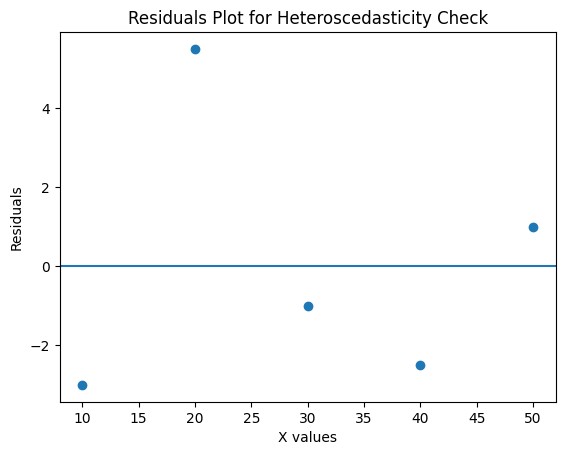

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Given data
X = np.array([10, 20, 30, 40, 50]).reshape(-1, 1)
Y = np.array([15, 35, 40, 50, 65])

# Train regression model
model = LinearRegression()
model.fit(X, Y)

# Predictions
Y_pred = model.predict(X)

# Residuals
residuals = Y - Y_pred

# Residuals plot
plt.scatter(X, residuals)
plt.axhline(y=0)
plt.xlabel("X values")
plt.ylabel("Residuals")
plt.title("Residuals Plot for Heteroscedasticity Check")
plt.show()


Q10: Imagine you are a data scientist working for a real estate company.
You need to predict house prices using features like area, number of rooms, and location.However, you detect heteroscedasticity and multicollinearity in your regression model. Explain the steps you would take to address these issues and ensure a robust model.


Ans- 
As a data scientist, I would take the following steps to build a robust house price prediction model:

#### 1. Detect the Problems
Use residual plots to identify heteroscedasticity and calculate VIF (Variance Inflation Factor) to detect multicollinearity among features.

#### 2. Handle Heteroscedasticity
Apply transformations such as log or square root on the target variable (price) or use robust standard errors to reduce unequal error variance.

#### 3. Handle Multicollinearity
Remove highly correlated variables, combine related features, or use regularization techniques like Ridge Regression.

#### 4. Re-train the Model
Fit the regression model again using the corrected features and transformed data.

#### 5. Validate the Model
Check residual plots, VIF values, and performance metrics to ensure assumptions are satisfied